# Clustering — Pré-processamento
Prepara a matriz de features normalizada usada pelos 3 algoritmos de clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('../dataset/ai_job_impact.csv')
print(f'Shape original: {df.shape}')
df.head(3)

Shape original: (2000, 17)


,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05


## 1. Remover colunas irrelevantes para clustering

In [2]:
# Employee_ID é apenas identificador
# Job_Status é o label supervisionado — não entra como feature de clustering
# Salary_After_AI é resultado pós-IA, pode vazar informação do target
df_clean = df.drop(columns=['Employee_ID', 'Job_Status', 'Salary_After_AI'])
print('Colunas mantidas:', df_clean.columns.tolist())

Colunas mantidas: ['Age', 'Gender', 'Education_Level', 'Industry', 'Job_Role', 'Years_Experience', 'AI_Adoption_Level', 'Automation_Risk', 'Upskilling_Required', 'Salary_Before_AI', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction', 'Productivity_Change_%']


## 2. Codificação de variáveis categóricas
Usamos **ordinal encoding** para variáveis com ordem natural e **one-hot** para as demais.

In [3]:
df_enc = df_clean.copy()

# Verificar valores únicos antes de mapear (evita NaN silencioso)
for col in ['Gender', 'Upskilling_Required', 'Remote_Work',
            'Education_Level', 'AI_Adoption_Level', 'Automation_Risk']:
    print(f'{col}: {sorted(df_enc[col].dropna().unique())}')

# Binárias (somente colunas com exatamente 2 valores)
# Gender tem 3 valores (Female/Male/Other) → vai para one-hot no próximo passo
df_enc['Upskilling_Required'] = df_enc['Upskilling_Required'].map({'No': 0, 'Yes': 1})
df_enc['Remote_Work']         = df_enc['Remote_Work'].map({'No': 0, 'Yes': 1})

# Ordinais com ordem natural
df_enc['Education_Level']   = df_enc['Education_Level'].map(
    {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3})
df_enc['AI_Adoption_Level'] = df_enc['AI_Adoption_Level'].map(
    {'Low': 0, 'Medium': 1, 'High': 2})
df_enc['Automation_Risk']   = df_enc['Automation_Risk'].map(
    {'Low': 0, 'Medium': 1, 'High': 2})

print('\nNaN por coluna após mappings (deve ser zero em todas):')
nulos = df_enc.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else 'Nenhum NaN encontrado.')
print('\nTipos das colunas:')
print(df_enc.dtypes)

Gender: ['Female', 'Male', 'Other']
Upskilling_Required: ['No', 'Yes']
Remote_Work: ['No', 'Yes']
Education_Level: ['Bachelor', 'High School', 'Master', 'PhD']
AI_Adoption_Level: ['High', 'Low', 'Medium']
Automation_Risk: ['High', 'Low', 'Medium']

NaN por coluna após mappings (deve ser zero em todas):
Nenhum NaN encontrado.

Tipos das colunas:
Age                        int64
Gender                       str
Education_Level            int64
Industry                     str
Job_Role                     str
Years_Experience           int64
AI_Adoption_Level          int64
Automation_Risk            int64
Upskilling_Required        int64
Salary_Before_AI           int64
Work_Hours_Per_Week        int64
Remote_Work                int64
Job_Satisfaction           int64
Productivity_Change_%    float64
dtype: object


In [4]:
# One-hot para Gender (3 valores), Industry e Job_Role (nominais sem ordem)
df_enc = pd.get_dummies(df_enc, columns=['Gender', 'Industry', 'Job_Role'], drop_first=False, dtype=int)

# Garantir que tudo é float (necessário para o StandardScaler)
df_enc = df_enc.astype(float)

# Verificação final de NaN
nulos_finais = df_enc.isnull().sum().sum()
print(f'Total de NaN após encoding: {nulos_finais}  {"✓ OK" if nulos_finais == 0 else "⚠ ATENÇÃO"}')
print(f'Shape após encoding: {df_enc.shape}')
df_enc.head(3)

Total de NaN após encoding: 0  ✓ OK
Shape após encoding: (2000, 42)


,Age,Education_Level,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,...,Job_Role_Nurse,Job_Role_Professor,Job_Role_Quality Inspector,Job_Role_SEO Specialist,Job_Role_Sales Associate,Job_Role_Software Engineer,Job_Role_Store Manager,Job_Role_Supervisor,Job_Role_Teacher,Job_Role_Technician
0,50.0,1.0,26.0,2.0,2.0,1.0,106820.0,45.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,45.0,0.0,19.0,0.0,0.0,1.0,74131.0,36.0,1.0,6.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,51.0,2.0,28.0,1.0,1.0,1.0,35311.0,46.0,1.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Normalização (StandardScaler)
Clustering baseado em distância (K-Means, DBSCAN) é sensível à escala das features.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_enc)

print(f'Matriz normalizada: {X_scaled.shape}')
print(f'Média por coluna (deve ser ~0): {X_scaled.mean(axis=0)[:5].round(4)}')
print(f'Desvio padrão por coluna (deve ser ~1): {X_scaled.std(axis=0)[:5].round(4)}')

Matriz normalizada: (2000, 42)
Média por coluna (deve ser ~0): [ 0. -0.  0. -0. -0.]
Desvio padrão por coluna (deve ser ~1): [1. 1. 1. 1. 1.]


## 4. Salvar artefatos para os próximos notebooks

In [6]:
import pickle

# Salvar matriz e metadados
np.save('../dataset/X_scaled.npy', X_scaled)

with open('../dataset/preprocessamento.pkl', 'wb') as f:
    pickle.dump({
        'scaler': scaler,
        'feature_names': df_enc.columns.tolist(),
        'df_original': df
    }, f)

print('Salvo:')
print('  ../dataset/X_scaled.npy       -> matriz normalizada')
print('  ../dataset/preprocessamento.pkl -> scaler + nomes das features + df original')

Salvo:
  ../dataset/X_scaled.npy       -> matriz normalizada
  ../dataset/preprocessamento.pkl -> scaler + nomes das features + df original


## 5. Visualização PCA — prévia dos dados (2D)

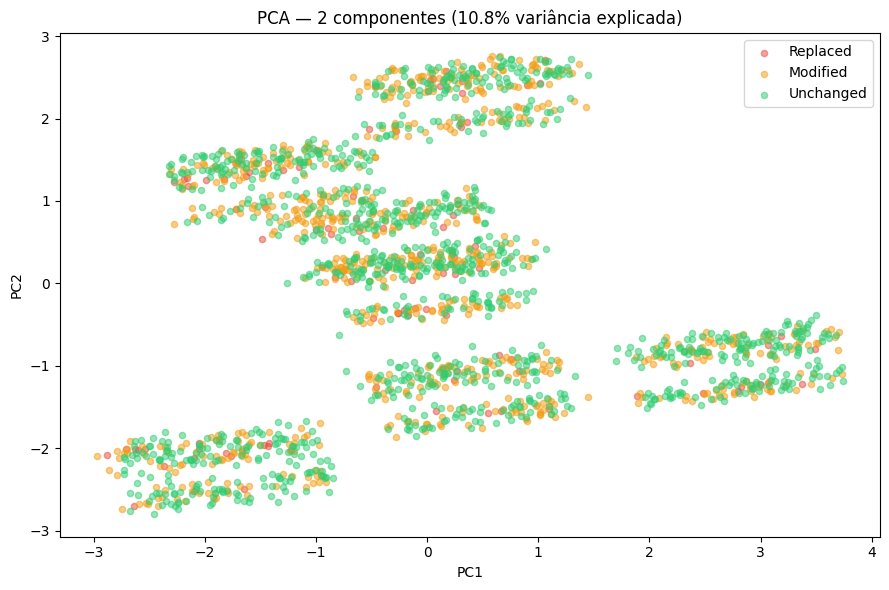

Variância explicada por componente: [0.054 0.054]


In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

job_status = df['Job_Status'].values
cores = {'Replaced': '#e74c3c', 'Modified': '#f39c12', 'Unchanged': '#2ecc71'}

plt.figure(figsize=(9, 6))
for status, cor in cores.items():
    mask = job_status == status
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=cor, label=status, alpha=0.5, s=20)

plt.title(f'PCA — 2 componentes ({pca.explained_variance_ratio_.sum()*100:.1f}% variância explicada)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

print('Variância explicada por componente:', pca.explained_variance_ratio_.round(3))